# Neural Architecture Search with Optuna

This notebook demonstrates lightweight Neural Architecture Search for Fashion-MNIST. Optuna automatically explores architecture and training choices while keeping the experiment practical on CPU.


In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import optuna
from tensorflow import keras
from tensorflow.keras import layers

SEED=42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:',tf.__version__)
print('Optuna:',optuna.__version__)


TensorFlow: 2.21.0
Optuna: 4.9.0


## 1. Load the dataset

Fashion-MNIST contains 28×28 grayscale clothing images. A small subset is used to keep NAS practical on CPU.


In [2]:
(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()
SEARCH_SAMPLES=6000; VAL_SAMPLES=1000; TEST_SAMPLES=1000
x_search=x_train[:SEARCH_SAMPLES].astype('float32')/255.0
y_search=y_train[:SEARCH_SAMPLES]
x_val=x_train[SEARCH_SAMPLES:SEARCH_SAMPLES+VAL_SAMPLES].astype('float32')/255.0
y_val=y_train[SEARCH_SAMPLES:SEARCH_SAMPLES+VAL_SAMPLES]
x_test_small=x_test[:TEST_SAMPLES].astype('float32')/255.0
y_test_small=y_test[:TEST_SAMPLES]
print(x_search.shape,x_val.shape,x_test_small.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(6000, 28, 28) (1000, 28, 28) (1000, 28, 28)


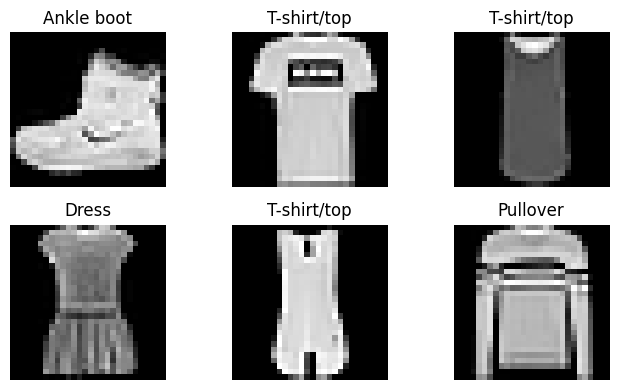

In [3]:
labels=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
plt.figure(figsize=(7,4))
for i in range(6):
    plt.subplot(2,3,i+1); plt.imshow(x_search[i],cmap='gray'); plt.title(labels[y_search[i]]); plt.axis('off')
plt.tight_layout(); plt.show()


## 2. Define the NAS search space

Optuna searches hidden-layer count, units, dropout, learning rate, and batch size.


In [4]:
def build_model(trial):
    model=keras.Sequential([layers.Input(shape=(28,28)),layers.Flatten()])
    n_layers=trial.suggest_int('n_layers',1,3)
    for i in range(n_layers):
        units=trial.suggest_categorical(f'units_{i}',[32,64,96,128])
        dropout=trial.suggest_float(f'dropout_{i}',0.0,0.4,step=0.1)
        model.add(layers.Dense(units,activation='relu'))
        if dropout>0: model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10,activation='softmax'))
    lr=trial.suggest_float('learning_rate',1e-4,3e-3,log=True)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

def objective(trial):
    model=build_model(trial)
    batch=trial.suggest_categorical('batch_size',[32,64,128])
    history=model.fit(x_search,y_search,validation_data=(x_val,y_val),epochs=3,batch_size=batch,verbose=0)
    return max(history.history['val_accuracy'])


## 3. Run the architecture search

The default is only 8 trials. Increase `N_TRIALS` gradually on a faster machine.


In [5]:
N_TRIALS=8
study=optuna.create_study(direction='maximize',study_name='fashion_mnist_nas')
study.optimize(objective,n_trials=N_TRIALS)
print('Best validation accuracy:',round(study.best_value,4))
print('\nBest parameters:')
for key,value in study.best_params.items(): print(f'{key}: {value}')


[I 2026-10-03 12:21:03,666] A new study created in memory with name: fashion_mnist_nas


[I 2026-10-03 12:21:47,734] Trial 0 finished with value: 0.6610000133514404 and parameters: {'n_layers': 3, 'units_0': 32, 'dropout_0': 0.2, 'units_1': 64, 'dropout_1': 0.2, 'units_2': 32, 'dropout_2': 0.1, 'learning_rate': 0.00013157248036671374, 'batch_size': 32}. Best is trial 0 with value: 0.6610000133514404.
[I 2026-10-03 12:22:31,238] Trial 1 finished with value: 0.7480000257492065 and parameters: {'n_layers': 3, 'units_0': 64, 'dropout_0': 0.0, 'units_1': 32, 'dropout_1': 0.4, 'units_2': 64, 'dropout_2': 0.1, 'learning_rate': 0.0005579072348416367, 'batch_size': 64}. Best is trial 1 with value: 0.7480000257492065.
[I 2026-10-03 12:22:41,678] Trial 2 finished with value: 0.828000009059906 and parameters: {'n_layers': 1, 'units_0': 96, 'dropout_0': 0.1, 'learning_rate': 0.0014662821710560016, 'batch_size': 32}. Best is trial 2 with value: 0.828000009059906.
[I 2026-10-03 12:22:49,396] Trial 3 finished with value: 0.8180000185966492 and parameters: {'n_layers': 2, 'units_0': 32, 'd

Best validation accuracy: 0.828

Best parameters:
n_layers: 1
units_0: 96
dropout_0: 0.1
learning_rate: 0.0014662821710560016
batch_size: 32


In [6]:
study.trials_dataframe()[['number','value','state']].sort_values('value',ascending=False).head(10)


,number,value,state
2,2,0.828,COMPLETE
3,3,0.818,COMPLETE
5,5,0.811,COMPLETE
4,4,0.807,COMPLETE
6,6,0.772,COMPLETE
7,7,0.753,COMPLETE
1,1,0.748,COMPLETE
0,0,0.661,COMPLETE


## 4. Train the discovered architecture

The best Optuna configuration is rebuilt and trained again. The saved model is used by Django.


In [7]:
best_trial=optuna.trial.FixedTrial(study.best_params)
best_model=build_model(best_trial)
best_model.summary()
history=best_model.fit(x_search,y_search,validation_data=(x_val,y_val),epochs=5,batch_size=study.best_params['batch_size'],verbose=1)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 96)             │        75,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │           970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,330 (298.16 KB)

 Trainable params: 76,330 (298.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6987 - loss: 0.8403 - val_accuracy: 0.7950 - val_loss: 0.5840
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8057 - loss: 0.5588 - val_accuracy: 0.8250 - val_loss: 0.5257
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8330 - loss: 0.4760 - val_accuracy: 0.8360 - val_loss: 0.4781
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8445 - loss: 0.4334 - val_accuracy: 0.8300 - val_loss: 0.4778
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8587 - loss: 0.3996 - val_accuracy: 0.8480 - val_loss: 0.4271


In [8]:
test_loss,test_accuracy=best_model.evaluate(x_test_small,y_test_small,verbose=0)
print(f'Test accuracy on {TEST_SAMPLES} examples: {test_accuracy:.4f}')
os.makedirs('../models',exist_ok=True)
best_model.save('../models/best_nas_model.keras')
print('Saved: ../models/best_nas_model.keras')


Test accuracy on 1000 examples: 0.8400
Saved: ../models/best_nas_model.keras


## 5. Inspect predictions


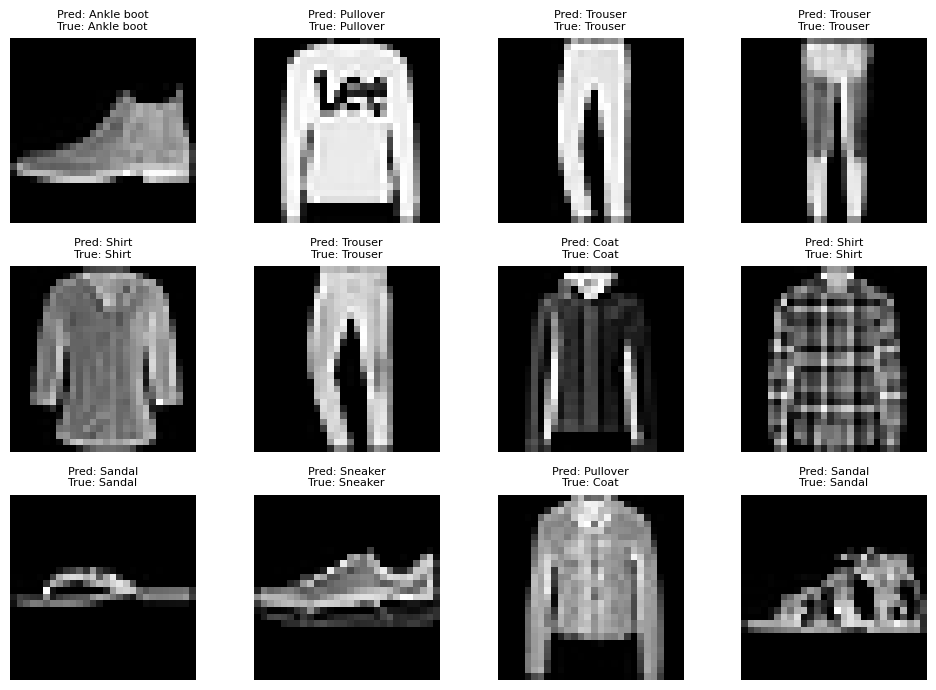

In [9]:
probabilities=best_model.predict(x_test_small[:12],verbose=0)
predictions=np.argmax(probabilities,axis=1)
plt.figure(figsize=(10,7))
for i in range(12):
    plt.subplot(3,4,i+1); plt.imshow(x_test_small[i],cmap='gray'); plt.title(f'Pred: {labels[predictions[i]]}\nTrue: {labels[y_test_small[i]]}',fontsize=8); plt.axis('off')
plt.tight_layout(); plt.show()


## Conclusion

The architecture is not manually fixed. Optuna evaluates candidates from the search space using validation accuracy, selects the best configuration, and the resulting model is saved for the Django demonstration.
